In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report



sns.set_style("whitegrid")

In [22]:
import os

🏦 Loan Approval Prediction - Machine Learning Project

This notebook presents an end-to-end machine learning workflow for predicting loan approval using applicant financial and demographic data.

The goal is to classify applicants as low-risk (approved) or high-risk (rejected) to support data-driven lending decisions.

In [23]:
os.getcwd()

'C:\\Users\\USER\\Desktop\\Loan_Prediction_Project\\Notebooks'

In [24]:
train_df = pd.read_csv(r"C:\Users\USER\Desktop\Loan_Prediction_Project\Data\Loan_Dataset\train.csv")
train_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [25]:
# Dataset shape
train_df.shape

(614, 13)

## 📂 Data Loading

In this section, we load the dataset and inspect its structure to understand available features and target variables.

In [26]:
# Column names
train_df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [27]:
train_df.info()
train_df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


## 🔍 Initial Data Exploration

We examine the dataset structure, data types, and summary statistics to gain an initial understanding of the data.

In [28]:
train_df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

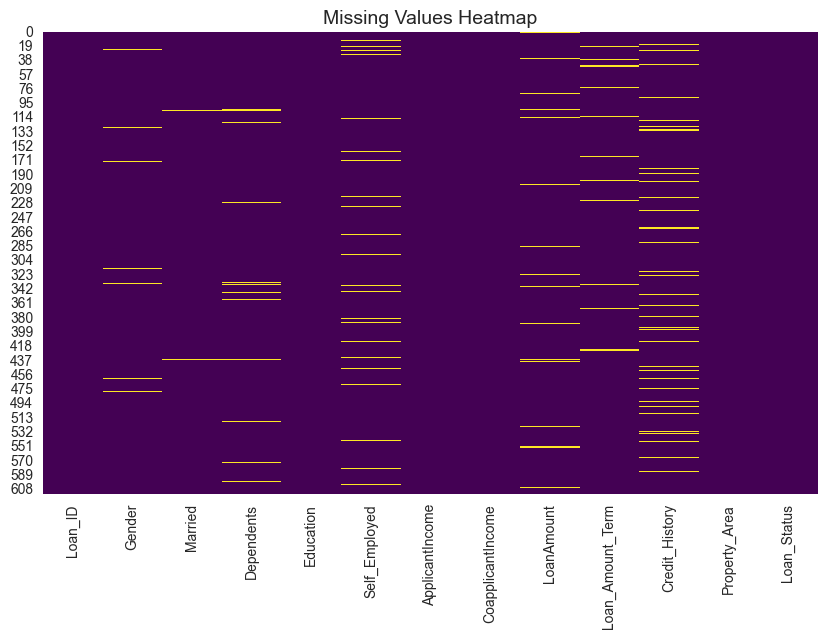

In [29]:
plt.figure(figsize=(10, 6))
sns.heatmap(train_df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap", fontsize=14)
plt.show()

## ⚠️ Missing Values Analysis

We identify missing values across features and visualize their distribution to guide data cleaning strategies.

In [30]:
# Categorical columns → fill with most frequent value (mode)
train_df['Gender'] = train_df['Gender'].fillna(train_df['Gender'].mode()[0])
train_df['Married'] = train_df['Married'].fillna(train_df['Married'].mode()[0])
train_df['Dependents'] = train_df['Dependents'].fillna(train_df['Dependents'].mode()[0])
train_df['Self_Employed'] = train_df['Self_Employed'].fillna(train_df['Self_Employed'].mode()[0])

# Numerical columns → fill with median (robust to outliers)
train_df['LoanAmount'] = train_df['LoanAmount'].fillna(train_df['LoanAmount'].median())
train_df['Loan_Amount_Term'] = train_df['Loan_Amount_Term'].fillna(train_df['Loan_Amount_Term'].median())
# Credit history → most important feature
train_df['Credit_History'] = train_df['Credit_History'].fillna(train_df['Credit_History'].mode()[0])

## 🧹 Data Cleaning

Missing values are handled using:
- Mode for categorical features
- Median for numerical features

This ensures robustness against outliers and preserves dataset integrity.

In [31]:
train_df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [32]:
# Label Encoder converts text labels to numbers
le = LabelEncoder()

# Apply encoding to all categorical columns
for col in train_df.select_dtypes(include='object').columns:
    train_df[col] = le.fit_transform(train_df[col])

train_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


🔄 Feature Encoding

Categorical variables are converted into numerical format using label encoding to make them suitable for machine learning models.

In [33]:
# X = input features
X = train_df.drop(['Loan_Status', 'Loan_ID'], axis=1)

# y = target variable
y = train_df['Loan_Status']

In [34]:
print(X.shape)
print(y.shape)

(614, 11)
(614,)


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## ✂️ Train-Test Split

The dataset is split into training and testing sets to evaluate model performance on unseen data.

In [36]:
print(np.mean(X_train, axis=0))  
print(np.std(X_train, axis=0))   

Gender                  0.810591
Married                 0.635438
Dependents              0.729124
Education               0.221996
Self_Employed           0.136456
ApplicantIncome      5502.645621
CoapplicantIncome    1676.488635
LoanAmount            148.046843
Loan_Amount_Term      340.765784
Credit_History          0.857434
Property_Area           1.036660
dtype: float64
Gender                  0.391833
Married                 0.481307
Dependents              1.008087
Education               0.415588
Self_Employed           0.343272
ApplicantIncome      5926.906614
CoapplicantIncome    3174.403963
LoanAmount             86.265563
Loan_Amount_Term       66.875817
Credit_History          0.349630
Property_Area           0.780803
dtype: float64


In [37]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Logistic Regression
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_logistic))

print(classification_report(y_test, y_pred_logistic))

Logistic Regression Accuracy: 0.7886178861788617
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



C:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


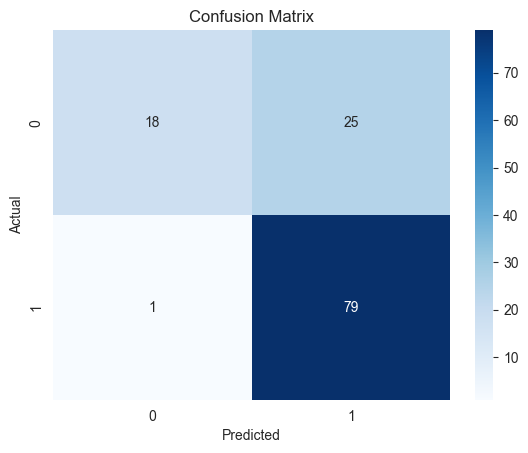

In [38]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_logistic)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [39]:
# Initialize Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,      # number of trees
    random_state=42,       # reproducibility
    class_weight='balanced' # optional, if your dataset is slightly imbalanced
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate performance
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))



from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numeric_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])



# Saving trainings
import joblib

joblib.dump(rf_model, "models/rf_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")

print("Model and scaler saved successfully!")

Random Forest Accuracy: 0.7723577235772358
              precision    recall  f1-score   support

           0       0.86      0.42      0.56        43
           1       0.75      0.96      0.85        80

    accuracy                           0.77       123
   macro avg       0.81      0.69      0.70       123
weighted avg       0.79      0.77      0.75       123

Model and scaler saved successfully!


## ⚙️ Feature Scaling

Numerical features are standardized using StandardScaler to ensure consistent feature ranges and improve model performance. 

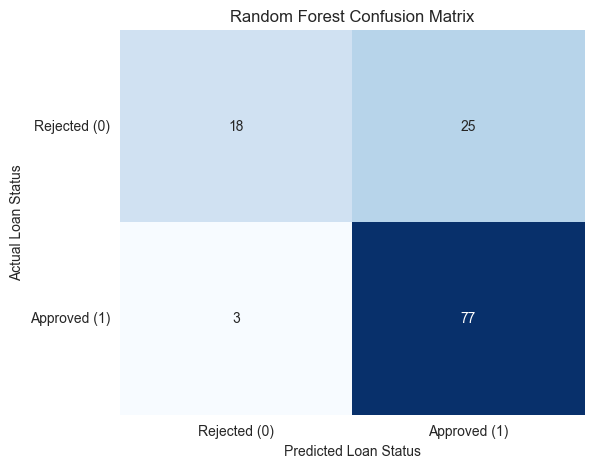

In [40]:

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted Loan Status")
plt.ylabel("Actual Loan Status")
plt.title("Random Forest Confusion Matrix")
plt.xticks([0.5, 1.5], ['Rejected (0)', 'Approved (1)'])
plt.yticks([0.5, 1.5], ['Rejected (0)', 'Approved (1)'], rotation=0)
plt.show()

In [44]:
# Initialize Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,       # number of trees
    random_state=42,        # reproducibility
    class_weight='balanced' # handle class imbalance
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred_rf)
report = classification_report(y_test, y_pred_rf, target_names=['Rejected (0)', 'Approved (1)'])

print("===== Random Forest Model Performance =====")
print(f"Accuracy: {accuracy:.2f}\n")
print("Classification Report:")
print(report)

# Optional: predict for a new applicant
# new_applicant = pd.DataFrame({...})  # replace with actual feature values
# prediction = rf_model.predict(new_applicant)
# print("\nPrediction for New Applicant:")
# if prediction[0] == 1:
#     print("Loan likely to be approved (low financial risk)")
# else:
#     print("Loan likely to be rejected (high financial risk)")

===== Random Forest Model Performance =====
Accuracy: 0.77

Classification Report:
              precision    recall  f1-score   support

Rejected (0)       0.86      0.42      0.56        43
Approved (1)       0.75      0.96      0.85        80

    accuracy                           0.77       123
   macro avg       0.81      0.69      0.70       123
weighted avg       0.79      0.77      0.75       123



## 📊 Model Evaluation

Models are evaluated using:
- Accuracy
- Precision
- Recall
- Confusion Matrix

This helps assess both overall performance and class-specific predictions.

In [45]:
import os
import joblib

# create folder 
os.makedirs("models", exist_ok=True)
joblib.dump(rf_model, "models/model.pkl")
print("Model saved successfully!")

Model saved successfully!


## 💾 Model Saving

The trained model and scaler are saved for future use in prediction and deployment.

## 🤖 Model Training

We train two models:
- Logistic Regression (baseline)
- Random Forest (captures non-linear relationships)

These models are evaluated to determine the best performer.

✅ Conclusion

This project demonstrates a complete machine learning pipeline from data preprocessing to model evaluation.

Key insights:
- Credit history is the most important factor in loan approval
- Income and loan amount significantly influence predictions
- Random Forest performs better in capturing complex patterns

The model can be used as a decision-support tool in financial institutions to improve loan approval processes.